In [1]:
import numpy as np
import pandas as pd
import zipfile
import os
import tensorflow as tf
from tensorflow import keras

In [2]:
# Extract the archive.zip file
def extract_zip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

In [3]:
# Paths
zip_path = '/content/archive.zip'  # Path to the archive.zip file65
extract_to = '/content/'  # Directory to extract the contents

# Extract the dataset
extract_zip(zip_path, extract_to)

In [4]:
BATCH_SIZE = 64
IMAGE_SIZE = (256, 256)

In [5]:
# Adjust the directory path
extract_path = '/content/Dataset'

In [6]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory=extract_path,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

Found 6400 files belonging to 4 classes.


In [7]:
classes  = dataset.class_names
classes

['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']

In [8]:
import matplotlib.pyplot as plt

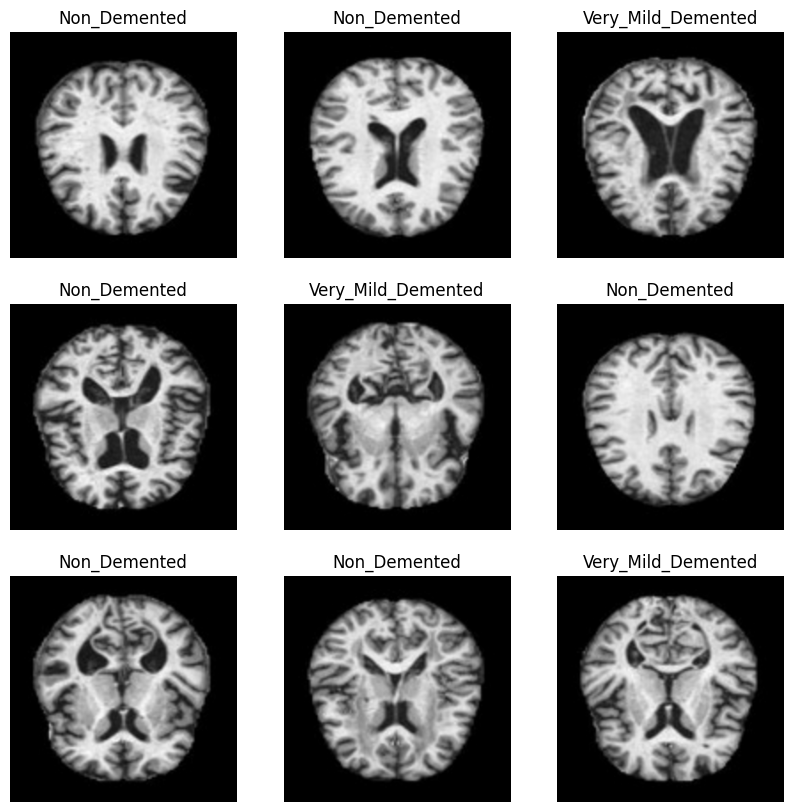

In [9]:
plt.figure(figsize=(10,10))
for images,labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(classes[labels[i]])
        plt.axis("off")

In [10]:
for image_batch, labels_batch in dataset:
  print(image_batch.shape)
  print(labels_batch.shape)

(64, 256, 256, 3)
(64,)


In [11]:
train_size = 0.8
len(dataset)*train_size

80.0

In [12]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [13]:
print(f"Train size: {len(train_ds)} \nTest size: {len(test_ds)} \nVal size: {len(val_ds)}")

Train size: 80 
Test size: 10 
Val size: 10


In [14]:
num_classes = 4
model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [15]:
model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy', 'recall', 'precision'])

In [16]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=10,
)

Epoch 1/10
80/80 [==============================] - 31s 222ms/step - loss: 1.0123 - accuracy: 0.5139 - val_loss: 0.9152 - val_accuracy: 0.5766
Epoch 2/10
80/80 [==============================] - 21s 172ms/step - loss: 0.8065 - accuracy: 0.6377 - val_loss: 0.6130 - val_accuracy: 0.7375
Epoch 3/10
80/80 [==============================] - 23s 210ms/step - loss: 0.5090 - accuracy: 0.7898 - val_loss: 0.3501 - val_accuracy: 0.8547
Epoch 4/10
80/80 [==============================] - 20s 170ms/step - loss: 0.2947 - accuracy: 0.8850 - val_loss: 0.1989 - val_accuracy: 0.9328
Epoch 5/10
80/80 [==============================] - 24s 209ms/step - loss: 0.1793 - accuracy: 0.9318 - val_loss: 0.0969 - val_accuracy: 0.9719
Epoch 6/10
80/80 [==============================] - 23s 211ms/step - loss: 0.0854 - accuracy: 0.9703 - val_loss: 0.0357 - val_accuracy: 0.9937
Epoch 7/10
80/80 [==============================] - 24s 211ms/step - loss: 0.0670 - accuracy: 0.9762 - val_loss: 0.0147 - val_accuracy: 0.9984

In [17]:
scores = model.evaluate(test_ds)

10/10 [==============================] - 6s 36ms/step - loss: 0.0114 - accuracy: 1.0000


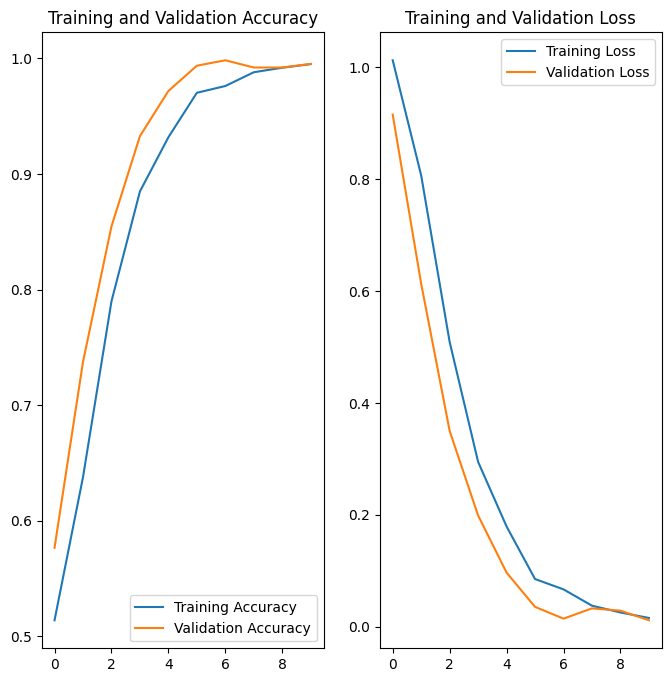

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
EPOCHS = 10
loss = history.history['loss']
val_loss = history.history['val_loss']
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Mild_Demented
2/2 [==============================] - 1s 14ms/step
predicted label: Mild_Demented


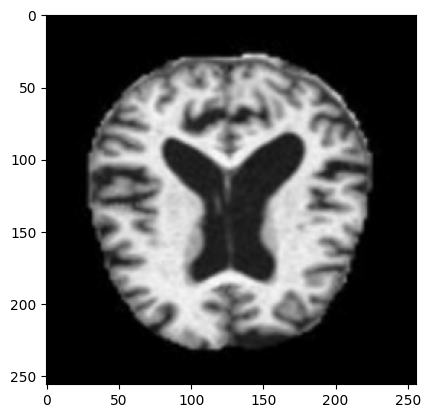

In [19]:
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",classes[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",classes[np.argmax(batch_prediction[0])])

In [20]:
def predict_mri(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = classes[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 24ms/step


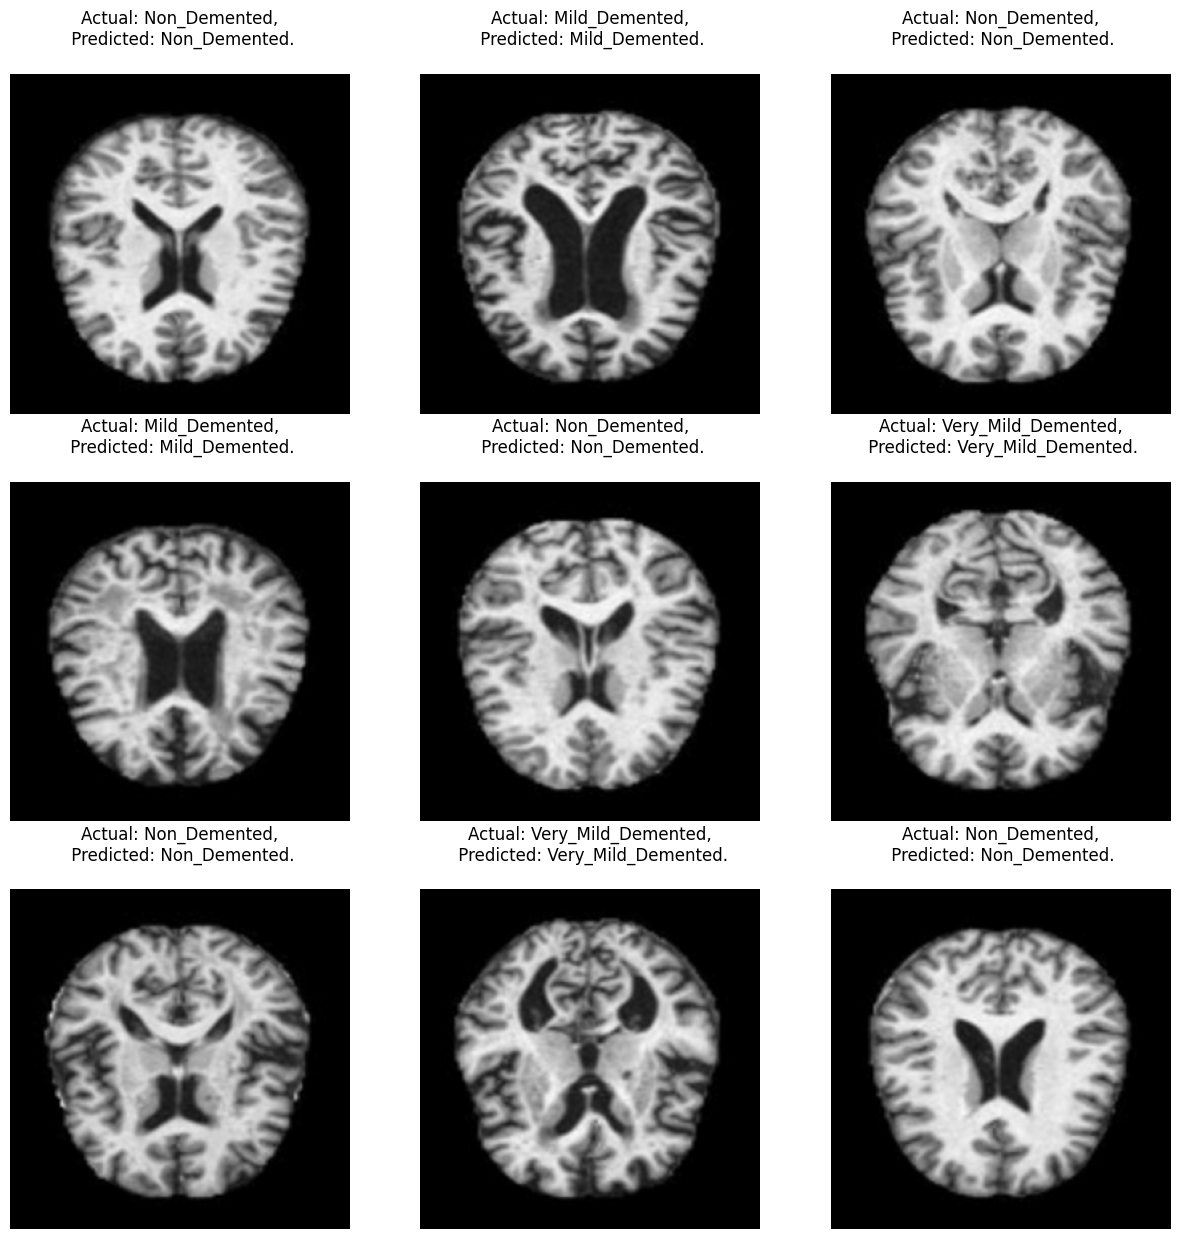

In [21]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict_mri(model, images[i].numpy())
        actual_class = classes[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n")

        plt.axis("off")

In [ ]:

def create_resnet101(image_size, num_classes):
    """
    Creates, compiles, prints a summary, and visualizes a model with MobileNetV3Small and ResNet101 branches.

    Parameters:
    - image_size: tuple, the input size of the images (height, width, channels).
    - num_classes: int, the number of classes for the classification task.

    Returns:
    - The compiled model.
    """
    # Load pre-trained models
    res101 = tf.keras.applications.ResNet101(include_top=False,
                                             weights='imagenet',
                                             input_shape=image_size)

    # Freeze layers in the base model
    for layer in res101.layers:
        layer.trainable = False

    # Create a sequential model
    model = tf.keras.Sequential()

    # Add the base model
    model.add(res101)

    # Add a global max pooling layer
    model.add(layers.GlobalMaxPooling2D())

    # Add a flatten layer
    model.add(layers.Flatten())

    # Add final classification layers
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Print model summary
    model.summary()

    # Visualize the model
    visualization_path = 'model_visualization.png'
    tf.keras.utils.plot_model(model, to_file=visualization_path, show_shapes=True, show_layer_names=True)

    print(f"Model visualization saved to {visualization_path}")

    return model


In [ ]:
single_model = create_resnet101(image_size, num_classes)

In [ ]:
history = single_model.fit(x_train, y_train_encoded, epochs=10, validation_split=0.2)

In [ ]:
print('Validation loss',np.mean(history.history['val_loss']))
print('Training loss',np.mean(history.history['loss']))
print('Validation Accuracy',np.mean(history.history['val_accuracy']))
print('Traing accuracy',np.mean(history.history['accuracy']))

In [ ]:
predictions = single_model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

print(classification_report(y_true, y_pred))
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
print('Accuracy:', accuracy_score(y_true, y_pred))
# Print metrics
print('Precision:', precision)
print('Recall:', recall)
print('F1-Score:', f1)